<a href="https://colab.research.google.com/github/danieljuanca23-hash/Algoritmos-de-Optimizacion/blob/main/Proyecto_Algoritmos_de_Optimizacion_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Juan Daniel Castillo Aguirre <br>
Url: https://github.com/danieljuanca23-hash/Algoritmos-de-Optimizacion/blob/main/Proyecto_Algoritmos_de_Optimizacion_V1.ipynbProblema:
> 1. Sesiones de doblaje <br>
>~2. Organizar los horarios de partidos de La Liga<br>~
>~3. Combinar cifras y operaciones~

*Descripción del problema:* <br>
Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las
tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de
grabación independientemente del número de tomas que se graben. No es posible grabar más
de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los
servicios de los actores de doblaje sea el menor posible.


# Sección 1
a)(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



b)¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.


### Punto 1. Número de posibilidades

**Modelo.** La solución planteada consiste en repartir las 30 tomas en días (grupos de grabación).
No influye el orden de los días ni el orden de las tomas dentro de un mismo día. Por tanto,
contar el número de soluciones equivale a contar las particiones del conjunto de las 30 tomas.

---

**a) Sin tener en cuenta las restricciones**

Si no imponemos ningún límite, cualquier agrupación es válida (un día puede contener entre 1 y 30
tomas, y puede haber entre 1 y 30 días). El número de particiones de un conjunto de $n$ elementos
es el número de Bell $B_n$, que se define mediante la recurrencia:

$$B_{n+1} = \sum_{k=0}^{n} \binom{n}{k}\, B_k, \qquad B_0 = 1$$

De forma equivalente, el número de Bell puede descomponerse mediante los números de
Stirling de segunda especie $S(n,k)$, que cuentan las particiones de un conjunto de $n$
elementos en exactamente $k$ grupos:

$$B_n = \sum_{k=1}^{n} S(n,k)$$

En el desarrollo de este ejercicio, $S(30,k)$ representa el número de formas de repartir las 30 tomas en
exactamente $k$ días. Así, $S(30,5)$ cuenta las planificaciones que usan 5 días, $S(30,6)$
las que usan 6 días, etc. El número de Bell $B_{30}$ suma todos esos casos (desde 1 hasta 30
días posibles), obteniendo el total de agrupaciones sin restricciones.

Para $n = 30$:

$$B_{30} = 846\,749\,014\,511\,809\,332\,450\,147 \approx 8{,}47 \times 10^{23}$$

---

**b) Teniendo en cuenta las restricciones**

La única restricción es que no se pueden grabar más de 6 tomas por día. Contamos entonces las
particiones del conjunto de 30 tomas en las que todo bloque tiene tamaño menor o igual que 6.

Fijando una toma cualquiera, su grupo puede tener tamaño $i \in \{1, \dots, 6\}$; elegimos sus $i-1$ compañeras entre las restantes y repartimos el resto de forma recursiva. Si $P(n)$ es el
número de particiones válidas de $n$ tomas:

$$P(n) = \sum_{i=1}^{\min(6,\,n)} \binom{n-1}{\,i-1\,}\, P(n-i), \qquad P(0) = 1$$

Para $n = 30$:

$$P(30) = 726\,391\,948\,970\,868\,949\,621\,309 \approx 7{,}26 \times 10^{23}$$

---

**Conclusión.** La restricción de 6 tomas por día apenas reduce el espacio de búsqueda
(de $8{,}47 \times 10^{23}$ a $7{,}26 \times 10^{23}$). Ambas cantidades son de un orden
inabarcable por fuerza bruta, lo que justifica el uso de algoritmos heurísticos para encontrar
una buena solución en un tiempo razonable.

# Comprobación en código del ejércicio 1

In [ ]:
from math import comb
from functools import lru_cache

## Número de Bell B(n): TODAS las formas de agrupar n tomas en días
## (Sin restricciones)
def bell(n):
    fila = [1]
    for i in range(1, n + 1):
        siguiente = [fila[-1]]
        for j in range(i):
            siguiente.append(siguiente[-1] + fila[j])
        fila = siguiente
    return fila[0]

## Particiones de n con bloques de tamaño <= k
## (Con restricción: se elige el grupo del primer elemento y repartimos el resto)
def particiones_max(n, k):
    @lru_cache(None)
    def f(m):
        if m == 0:
            return 1
        return sum(comb(m - 1, i - 1) * f(m - i) for i in range(1, min(k, m) + 1))
    return f(n)

## Funciones auxiliares que representan el valor absoluto de los valores
def formato(n):
    "Separa los miles con puntos: 846.749.014..."
    return f"{n:,}".replace(",", ".")

def cientifica(n):
    "Redondea a notación científica: 8,47 x 10^23"
    return f"{n:.2e}".replace("e+", " x 10^").replace(".", ",", 1)

TOMAS = 30
MAX_TOMAS_DIA = 6

sin_restr = bell(TOMAS)
con_restr = particiones_max(TOMAS, MAX_TOMAS_DIA)

print("Sin restricciones (Bell):")
print("Exacto:", formato(sin_restr))
print("Aprox.:", cientifica(sin_restr))
print("Con restricción (<= 6):")
print("Exacto:", formato(con_restr))
print("Aprox.:", cientifica(con_restr))

Sin restricciones (Bell):
Exacto: 846.749.014.511.809.332.450.147
Aprox.: 8,47 x 10^23
Con restricción (<= 6):
Exacto: 726.391.948.970.868.949.621.309
Aprox.: 7,26 x 10^23


# Sección 2


Modelo para el espacio de soluciones

(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, argumentalo)

### Punto 2. Estructura de datos

En este problema conviene distinguir dos representaciones: la de los datos de entrada y la
de una solución.

a) Datos de entrada (participación de actores en tomas)

Los datos se representan mediante una matriz binaria (lista de listas) de dimensión
$30 \times 10$, donde la fila $t$ corresponde a la toma $t$ y la columna $a$ al actor $a$:

$$M[t][a] = \begin{cases} 1 & \text{si el actor } a \text{ participa en la toma } t \\ 0 & \text{en caso contrario} \end{cases}$$

Se considera que es la representación más natural, pues es un calculo directo de la tabla del Excel y permite
acceder a cualquier dato en tiempo constante $O(1)$ mediante `M[t][a]`.

b) Cada toma como conjunto de actores

Para calcular el coste resulta más cómodo representar cada toma como un conjunto (`set`)
con los actores que participan en ella. El coste de un día es el número de actores distintos
que acuden, es decir, el cardinal de la unión de los conjuntos de las tomas grabadas ese día:

$$\text{coste}(dia) = \left| \bigcup_{t \in dia} \text{actores}(t) \right|$$

La operación de unión de conjuntos elimina automáticamente los actores repetidos, evitando
bucles y comprobaciones manuales que serían necesarios con la matriz.

c) Una solución (planificación)

Una solución se representa como una lista de listas: una lista de días, donde cada día es la
lista de tomas que se graban en él. Esta estructura refleja de forma directa el problema
(agrupar tomas en días), permite comprobar fácilmente la restricción de capacidad
($\lvert dia \rvert \le 6$) y es cómoda de recorrer para evaluar el coste total.

Justificación del cambio: Se parte de la matriz binaria por ser la forma directa de los
datos, pero se complementa con conjuntos porque la operación clave del problema que es contar actores distintos por día, se expresa de manera natural como una unión de conjuntos. Es un ejemplo de
cómo la estructura elegida inicialmente se enriquece al analizar la función objetivo.

In [ ]:
import pandas as pd

NOMBRE_FICHERO = "Datos problema doblaje(30 tomas, 10 actores).xlsx"

## a) Se cargan los datos del problema para leerlos
df = pd.read_excel(NOMBRE_FICHERO, header=None)
DOBLAJE = df.iloc[2:32, 1:11].astype(int).values.tolist()

NUM_TOMAS   = len(DOBLAJE)       # 30
NUM_ACTORES = len(DOBLAJE[0])    # 10

## b) Cada toma como CONJUNTO de actores
tomas_actores = [
    {actor + 1 for actor, participa in enumerate(fila) if participa == 1}
    for fila in DOBLAJE
]

## Comprobaciones
print("Nº de tomas  :", NUM_TOMAS)
print("Nº de actores:", NUM_ACTORES)
print("Toma 1  como conjunto:", tomas_actores[0])
print("Toma 16 como conjunto:", tomas_actores[15])

## Ejemplo: coste de un día con las tomas 1, 2 y 6
dia_ejemplo = [1, 2, 6]
actores_dia = set()
for t in dia_ejemplo:
    actores_dia |= tomas_actores[t - 1]
print("\nDía de ejemplo con tomas", dia_ejemplo)
print("  Actores necesarios:", actores_dia)
print("  Coste del día (actores distintos):", len(actores_dia))

Nº de tomas  : 30
Nº de actores: 10
Toma 1  como conjunto: {1, 2, 3, 4, 5}
Toma 16 como conjunto: {10, 4}

Día de ejemplo con tomas [1, 2, 6]
  Actores necesarios: {1, 2, 3, 4, 5}
  Coste del día (actores distintos): 5


# Sección 3

Según el modelo para el espacio de soluciones

(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

### Punto 3. Función objetivo y tipo de problema

Función objetivo

El coste de un día es el número de actores distintos que acuden ese día, ya que cada actor
cobra la misma cantidad por desplazarse, independientemente del número de tomas que grabe. Ese
coste diario es el cardinal de la unión de los conjuntos de actores de las tomas grabadas
ese día.

El coste de una solución completa es la suma de los costes de todos sus días. Si una solución
reparte las tomas en un conjunto de días $D$:

$$f(\text{solución}) = \sum_{d \in D} \left| \bigcup_{t \in d} \text{actores}(t) \right|$$

Es decir, para cada día se cuentan los actores distintos y se suman todos los días. A esta
magnitud la llamamos actor-días (el número total de desplazamientos que hay que pagar).

**Tipo de problema:** Minimización

Se trata de un problema de minimización, pues el objetivo es que el gasto por los servicios
de los actores sea el menor posible.

Buscamos la solución que minimiza $f$ sujeta a las restricciones:

- Cada día contiene como máximo 6 tomas: $\;|d| \le 6\;$ para todo $d \in D$.
- Cada toma se graba exactamente una vez (pertenece a un único día).

Intuición. El número de tomas es fijo (30), por lo que no se puede reducir el trabajo total.
Lo que sí se puede optimizar es agrupar en el mismo día las tomas que compartan actores: si
dos tomas usan actores muy parecidos, grabarlas juntas apenas añade coste, porque esos actores
ya se han desplazado ese día.


In [ ]:
## Coste de un día = nº de actores DISTINTOS que acuden. 'dia' es una lista de números de toma (empezando en 1).
def coste_dia(dia, tomas_actores):
    actores = set()
    for t in dia:
        actores |= tomas_actores[t - 1]   # unión: junta actores sin repetir
    return len(actores)

## Coste total de una solución = suma de los costes de todos sus días.'solucion' es una lista de días; cada día es una lista de tomas. ##
def funcion_objetivo(solucion, tomas_actores):
    return sum(coste_dia(dia, tomas_actores) for dia in solucion)


## Prueba con una solución de ejemplo (5 días de 6 tomas)
solucion_ejemplo = [
    [1, 2, 3, 4, 5, 6],
    [7, 8, 9, 10, 11, 12],
    [13, 14, 15, 16, 17, 18],
    [19, 20, 21, 22, 23, 24],
    [25, 26, 27, 28, 29, 30],
]

for i, dia in enumerate(solucion_ejemplo, 1):
    print(f"Día {i}: tomas {dia} -> {coste_dia(dia, tomas_actores)} actores")

print("\nCOSTE TOTAL (Actor-Días):", funcion_objetivo(solucion_ejemplo, tomas_actores))

Día 1: tomas [1, 2, 3, 4, 5, 6] -> 7 actores
Día 2: tomas [7, 8, 9, 10, 11, 12] -> 8 actores
Día 3: tomas [13, 14, 15, 16, 17, 18] -> 8 actores
Día 4: tomas [19, 20, 21, 22, 23, 24] -> 7 actores
Día 5: tomas [25, 26, 27, 28, 29, 30] -> 8 actores

COSTE TOTAL (Actor-Días): 38


# Sección 4


Diseña un algoritmo para resolver el problema por fuerza bruta

### Punto 4. Algoritmo por fuerza bruta

La estrategia de fuerza bruta consiste en explorar todas las soluciones posibles y quedarse
con la de menor coste, sin aplicar ningún criterio que reduzca la búsqueda. Garantiza encontrar
el óptimo, pero a costa de examinar el espacio de soluciones completo.

Pasos del algoritmo:

1. Generar todas las particiones posibles del conjunto de 30 tomas en días, respetando la
   restricción de un máximo de 6 tomas por día.
2. Evaluar cada partición con la función objetivo (suma de actores distintos por día).
3. Seleccionar la partición de menor coste.

Generación de las particiones. Se construyen de forma recursiva colocando las tomas una a
una. Para cada toma existen dos posibilidades:

- añadirla a un día ya iniciado, siempre que ese día tenga menos de 6 tomas, o
- abrir un día nuevo que empiece con esa toma.

Combinando ambas opciones para todas las tomas se obtienen todas las particiones válidas.

Limitación. Como se vio en el punto 1, el número de particiones válidas para 30 tomas es del
orden de $7{,}26 \times 10^{23}$. Aunque el algoritmo es correcto, resulta inviable en la
práctica: solo termina en un tiempo razonable para instancias muy pequeñas (aproximadamente
hasta 10-12 tomas). Esta explosión combinatoria puede influir en el replanteo del algoritmo.

In [ ]:
## Se generan TODAS las formas de repartir 'tomas' en días de <= max_por_dia.
## Estrategia recursiva: coloca las tomas una a una.
def generar_particiones(tomas, max_por_dia):
    if not tomas:     # Caso base: no quedan tomas
        yield []
        return
    primera, resto = tomas[0], tomas[1:]
    for particion in generar_particiones(resto, max_por_dia):
        # Opción A: añadir 'primera' a un día ya existente (si aún cabe)
        for i in range(len(particion)):
            if len(particion[i]) < max_por_dia:
                nueva = [list(dia) for dia in particion]
                nueva[i].append(primera)
                yield nueva
        # Opción B: 'primera' abre un día nuevo
        yield [[primera]] + [list(dia) for dia in particion]

## Prueba todas las particiones válidas y devuelve la de menor coste.
## Retorna: (mejor_solucion, mejor_coste, nº_particiones_evaluadas)
def fuerza_bruta(tomas, tomas_actores, max_por_dia=6):
    mejor_solucion = None
    mejor_coste = float('inf')
    evaluadas = 0
    for particion in generar_particiones(tomas, max_por_dia):
        evaluadas += 1
        coste = funcion_objetivo(particion, tomas_actores)
        if coste < mejor_coste:
            mejor_coste = coste
            mejor_solucion = particion
    return mejor_solucion, mejor_coste, evaluadas

# Prueba: demostración de la explosión combinatoria
print("=" * 58)
print("   DEMOSTRACIÓN DE LA EXPLOSIÓN COMBINATORIA")
print("=" * 58)
print(f"{'Nº tomas':>9} | {'Particiones':>15} | {'Coste óptimo':>12}")
print("-" * 58)

resultados = []
for N in [6, 8, 10]:
    tomas = list(range(1, N + 1))
    solucion, coste, evaluadas = fuerza_bruta(tomas, tomas_actores)
    resultados.append((N, solucion, coste))
    print(f"{N:>9} | {evaluadas:>15,} | {coste:>12}")

print("=" * 58)
print("\nMejor solución encontrada en cada caso:")
for N, solucion, coste in resultados:
    print(f"  • N={N:2d} (coste {coste}): {solucion}")

   DEMOSTRACIÓN DE LA EXPLOSIÓN COMBINATORIA
 Nº tomas |     Particiones | Coste óptimo
----------------------------------------------------------
        6 |             203 |            7
        8 |           4,131 |           12
       10 |         115,274 |           13

Mejor solución encontrada en cada caso:
  • N= 6 (coste 7): [[6, 5, 4, 3, 2, 1]]
  • N= 8 (coste 12): [[2, 1], [8, 7, 6, 5, 4, 3]]
  • N=10 (coste 13): [[5, 4, 3, 2, 1], [10, 9, 8, 7, 6]]


# Sección 5

Calcula la complejidad del algoritmo por fuerza bruta

### Punto 5. Complejidad del algoritmo por fuerza bruta

La complejidad se obtiene multiplicando dos factores: el número de soluciones que se examinan
por el coste de evaluar cada una.

1. Número de soluciones examinadas. La fuerza bruta recorre todas las particiones del
conjunto de $n$ tomas, es decir, el número de Bell $B(n)$ (con la restricción de 6 tomas por
día el número es algo menor, pero del mismo orden de magnitud). Este número crece de forma
super-exponencial: más deprisa que cualquier $c^n$, y acotado superiormente por el factorial,
$B(n) \le n!$.

El crecimiento se comprobó empíricamente en el punto 4:

| $n$ | Particiones evaluadas |
|----|----------------------|
| 6  | 203 |
| 8  | 4.131 |
| 10 | 115.274 |

2. Coste de evaluar cada solución. Aplicar la función objetivo recorre cada toma una vez y
une conjuntos de a lo sumo $A$ actores, con un coste polinómico de $O(n \cdot A)$, siendo $A$
el número de actores.

**Complejidad total:**

$$O\big(B(n) \cdot n \cdot A\big)$$

El término dominante es $B(n)$, de modo que el coste de evaluación resulta despreciable frente a
él. Se trata, por tanto, de un algoritmo de complejidad super-exponencial, intratable en
la práctica: solo termina en tiempo razonable para instancias muy pequeñas (aproximadamente hasta
10-12 tomas). Para $n = 30$ es completamente inviable, lo que justifica el diseño de un algoritmo
más eficiente en el punto 6.

n = 2  -> tiempo = 0.0 s
n = 3  -> tiempo = 0.0 s
n = 4  -> tiempo = 0.0001 s
n = 5  -> tiempo = 0.0001 s
n = 6  -> tiempo = 0.0005 s
n = 7  -> tiempo = 0.0024 s
n = 8  -> tiempo = 0.0127 s
n = 9  -> tiempo = 0.0695 s
n = 10  -> tiempo = 0.4158 s
n = 11  -> tiempo = 2.5771 s


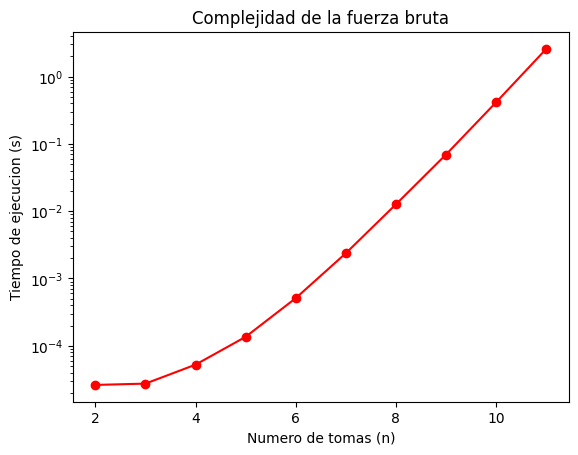

In [ ]:
import time
import matplotlib.pyplot as plt

tamanos = []      # Para guardar el número de tomas
tiempos = []      # Para guardar el tiempo de ejecución

for n in range(2, 12):                        # Se prueba con tamaños crecientes
  tomas = list(range(1, n + 1))
  inicio = time.time()                        # Marca de tiempo inicial
  fuerza_bruta(tomas, tomas_actores)          # Se ejecuta la fuerza bruta
  fin = time.time()                           # Marca de tiempo final
  tamanos.append(n)
  tiempos.append(fin - inicio)
  print("n =", n, " -> tiempo =", round(fin - inicio, 4), "s")

# Se grafica el crecimiento del tiempo segun el numero de tomas
plt.plot(tamanos, tiempos, "o-", c="red")     # Puntos unidos por lineas
plt.title("Complejidad de la fuerza bruta")
plt.xlabel("Numero de tomas (n)")
plt.ylabel("Tiempo de ejecucion (s)")
plt.yscale("log")                             # Escala logarítmica para ver la explosión
plt.show()

# Sección 6

(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

### Punto 6. Algoritmo que mejora la fuerza bruta: Búsqueda Local

En lugar de explorar todas las particiones posibles (fuerza bruta), se aplica una búsqueda
local con el operador de vecindad 2-opt, la misma técnica empleada en la Actividad Guiada 3
para el problema del viajante (TSP).

Representación de la solución. Una solución se modela como una permutación de las 30
tomas. Esa permutación se divide en días consecutivos de 6 tomas, obteniendo así los 5 días de
grabación (⌈30/6⌉ = 5). De este modo, cualquier orden de las tomas produce una planificación
válida que respeta automáticamente la restricción de capacidad.

Funcionamiento del algoritmo:

1. Se parte de una solución inicial aleatoria (una permutación al azar de las tomas).
2. Se generan sus vecinas mediante 2-opt: intercambiando la posición de dos tomas. Se elige
   la vecina de menor coste.
3. Si la mejor vecina mejora la solución actual, se avanza hacia ella; el proceso se repite.
4. Cuando ninguna vecina mejora, se ha alcanzado un mínimo local y el algoritmo termina.
5. Para reducir el riesgo de quedar atrapado en un mínimo local pobre, se aplican varios
   reinicios desde soluciones iniciales distintas, conservando el mejor resultado global.

Por qué mejora la fuerza bruta. La fuerza bruta examina el espacio completo de soluciones,
de tamaño super-exponencial (≈ $7{,}26 \times 10^{23}$), lo que la hace inviable. La búsqueda
local no recorre todo el espacio: sigue una trayectoria guiada por la función objetivo,
evaluando en cada paso únicamente las vecinas inmediatas (del orden de $\binom{n}{2}$
intercambios) y avanzando hacia soluciones cada vez mejores. Así, el número de evaluaciones pasa
de super-exponencial a polinómico, obteniendo una solución de gran calidad en una fracción de
segundo. Como contrapartida, no garantiza el óptimo global como característica propia de las
heurísticas, pero en la práctica alcanza soluciones muy próximas al óptimo.

**Resultado obtenido:** La búsqueda local reduce el coste de 38 actor-días (agrupación
trivial por tomas consecutivas) a 28 actor-días, en aproximadamente 0,16 segundos.

In [ ]:
import random
# No se pueden grabar mas de 6 tomas/día
TOMAS_POR_DIA = 6

# Genera una solución aleatoria: una permutación de las tomas
def crear_solucion(num_tomas):
  solucion = list(range(1, num_tomas + 1))
  random.shuffle(solucion)
  return solucion

# Divide la permutación en días consecutivos de 6 tomas
def dividir_en_dias(solucion):
  return [solucion[i:i + TOMAS_POR_DIA] for i in range(0, len(solucion), TOMAS_POR_DIA)]

# Función objetivo sobre una permutación (recibe los datos por parametro)
def coste_total(solucion, tomas_actores):
  return funcion_objetivo(dividir_en_dias(solucion), tomas_actores)

# Generador de vecinas 2-opt: intercambia 2 tomas y devuelve la mejor
def genera_vecina(solucion, tomas_actores):
  mejor_solucion = solucion
  mejor_coste = coste_total(solucion, tomas_actores)
  for i in range(len(solucion) - 1):
    for j in range(i + 1, len(solucion)):
      vecina = solucion[:]
      vecina[i], vecina[j] = vecina[j], vecina[i]
      coste_vecina = coste_total(vecina, tomas_actores)
      if coste_vecina < mejor_coste:
        mejor_coste = coste_vecina
        mejor_solucion = vecina
  return mejor_solucion

# Busqueda local: mejora hasta que ninguna vecina mejore (mínimo local)
def busqueda_local(num_tomas, tomas_actores):
  solucion = crear_solucion(num_tomas)
  coste = coste_total(solucion, tomas_actores)
  while True:
    vecina = genera_vecina(solucion, tomas_actores)
    coste_vecina = coste_total(vecina, tomas_actores)
    if coste_vecina < coste:
      solucion = vecina
      coste = coste_vecina
    else:
      return solucion, coste

# Búsqueda local con varios reinicios (evita mínimos locales pobres)
def busqueda_local_reinicios(num_tomas, tomas_actores, reinicios=20):
  mejor_solucion = None
  mejor_coste = float('inf')
  for _ in range(reinicios):
    solucion, coste = busqueda_local(num_tomas, tomas_actores)
    if coste < mejor_coste:
      mejor_coste = coste
      mejor_solucion = solucion
  return mejor_solucion, mejor_coste

# Ejecución sobre los datos problema doblaje
random.seed(42)                                     # Semilla para reproducibilidad
solucion, coste = busqueda_local_reinicios(NUM_TOMAS, tomas_actores, 20)

print("Coste de referencia (tomas consecutivas):", coste_total(list(range(1, NUM_TOMAS + 1)), tomas_actores))
print("Mejor coste con busqueda local          :", coste)
print("\nPlanificacion encontrada:")
for i, dia in enumerate(dividir_en_dias(solucion), 1):
  print(f"  Dia {i}: tomas {sorted(dia)} -> {coste_dia(dia, tomas_actores)} actores")

Coste de referencia (tomas consecutivas): 38
Mejor coste con busqueda local          : 28

Planificacion encontrada:
  Dia 1: tomas [14, 17, 18, 19, 23, 24] -> 3 actores
  Dia 2: tomas [3, 4, 8, 11, 15, 21] -> 7 actores
  Dia 3: tomas [10, 12, 20, 26, 27, 29] -> 7 actores
  Dia 4: tomas [1, 2, 16, 22, 25, 30] -> 6 actores
  Dia 5: tomas [5, 6, 7, 9, 13, 28] -> 5 actores


# Sección 7

(*)Calcula la complejidad del algoritmo

### Punto 7. Complejidad del algoritmo de búsqueda local

Sea $n$ el número de tomas y $A$ el número de actores. La complejidad se obtiene analizando cada
función y combinándolas por capas.

1. `coste_total` (evaluar una solución). Divide la permutación en días y suma los actores
distintos de cada día, recorriendo cada toma una vez y realizando uniones de conjuntos:

$$O(n \cdot A)$$

2. `genera_vecina` (explorar el vecindario 2-opt). Recorre todos los pares de tomas $(i,j)$
mediante un doble bucle, generando $\binom{n}{2} \approx n^2/2$ vecinas, y evalúa cada una con
`coste_total`:

$$O(n^2) \times O(n \cdot A) = O(n^3 \cdot A)$$

3. `busqueda_local` (iterar hasta el mínimo local). Invoca `genera_vecina` en cada paso de
mejora. Si realiza $k$ pasos (número reducido y acotado, ya que el coste solo puede decrecer):

$$O(k \cdot n^3 \cdot A)$$

4. Reinicios. Con $R$ reinicios desde soluciones iniciales distintas:

$$O(R \cdot k \cdot n^3 \cdot A)$$

Complejidad final. Como $A$, $k$ y $R$ son constantes acotadas, el término dominante es
$n^3$, por lo que la complejidad es polinómica (cúbica):

$$O(n^3)$$

La comparación con la fuerza bruta. Se pasa de una complejidad super-exponencial
($O(B(n) \cdot n)$, inviable para $n=30$) a una complejidad polinómica $O(n^3)$, que se
ejecuta de forma prácticamente instantánea. Esta reducción es la que justifica la mejora respecto
a la fuerza bruta: a cambio de no garantizar el óptimo global, se obtiene una solución de gran
calidad en un tiempo muchísimo menor.

Nota: la complejidad podría reducirse aún más evaluando únicamente los días afectados por cada
intercambio evaluación incremental, lo que bajaría el coste de cada vecina a $O(n^2 \cdot A)$
por pasada. Para el tamaño del problema, la versión actual es suficiente.

# Sección 8

Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

### Punto 8. Juego de datos de entrada aleatorio

Para poder probar el algoritmo con distintos escenarios (y no solo con los datos del enunciado),
se diseña un generador de matrices de doblaje aleatorias. La función recibe como parámetros:

- **`num_tomas`**: número de tomas a generar.
- **`num_actores`**: número de actores disponibles.
- **`prob`**: probabilidad de que un actor participe en una toma. Regula la densidad de la matriz
  (a mayor valor, tomas con más actores).
- **`semilla`**: valor opcional para fijar el generador aleatorio y poder reproducir el mismo
  juego de datos.

Para cada toma, cada actor participa de forma independiente con probabilidad `prob`. Como una
toma sin ningún actor **no tendría sentido** en el problema (no se puede doblar una escena sin
intérpretes), se garantiza que toda toma tenga al menos un actor: si una fila queda vacía, se
le asigna un actor al azar.

Se incluye además una función auxiliar que convierte la matriz generada en la lista de conjuntos
de actores por toma, de modo que el juego de datos aleatorio queda listo para ser utilizado
directamente por el algoritmo de búsqueda local (punto 9).

Este generador permite validar el algoritmo con múltiples instancias de distintos tamaños,
comprobar su robustez (que no funcione bien únicamente con los datos concretos del enunciado)
y generar casos grandes para verificar empíricamente la complejidad analizada en el punto 7.

In [ ]:
import random
# Se genera una matriz de doblaje aleatoria (tomas x actores)
def generar_datos(num_tomas, num_actores, prob=0.3, semilla=None):
  if semilla is not None:
    random.seed(semilla)                            # Para poder reproducir el mismo juego
  matriz = []
  for _ in range(num_tomas):
    # Cada actor participa en la toma con probabilidad 'prob'
    fila = [1 if random.random() < prob else 0 for _ in range(num_actores)]
    # Nos aseguramos de que la toma tenga al menos 1 actor (si no, no tiene sentido)
    if sum(fila) == 0:
      fila[random.randrange(num_actores)] = 1
    matriz.append(fila)
  return matriz

# Convierte una matriz en la lista de conjuntos de actores por toma
def matriz_a_conjuntos(matriz):
  return [{a + 1 for a, v in enumerate(fila) if v == 1} for fila in matriz]


# Prueba: generamos un juego pequeno para verlo
datos = generar_datos(num_tomas=8, num_actores=5, prob=0.4, semilla=1)
print("Matriz de doblaje aleatoria (8 tomas x 5 actores):")
for i, fila in enumerate(datos, 1):
  print(f"  Toma {i}: {fila}")

conjuntos = matriz_a_conjuntos(datos)
print("\nComo conjuntos de actores:")
for i, c in enumerate(conjuntos, 1):
  print(f"  Toma {i}: {c}")

Matriz de doblaje aleatoria (8 tomas x 5 actores):
  Toma 1: [1, 0, 0, 1, 0]
  Toma 2: [0, 0, 0, 1, 1]
  Toma 3: [0, 0, 0, 1, 0]
  Toma 4: [0, 1, 0, 0, 1]
  Toma 5: [1, 0, 0, 1, 1]
  Toma 6: [0, 1, 1, 0, 0]
  Toma 7: [1, 1, 1, 0, 1]
  Toma 8: [1, 0, 0, 0, 1]

Como conjuntos de actores:
  Toma 1: {1, 4}
  Toma 2: {4, 5}
  Toma 3: {4}
  Toma 4: {2, 5}
  Toma 5: {1, 4, 5}
  Toma 6: {2, 3}
  Toma 7: {1, 2, 3, 5}
  Toma 8: {1, 5}


# Sección 9


Aplica el algoritmo al juego de datos generado

### Punto 9. Aplicación del algoritmo al juego de datos aleatorio

En este apartado se comprueba que el algoritmo de búsqueda local es general: se aplica a una
instancia generada aleatoriamente con el generador del punto 8, en lugar de a los datos concretos
del enunciado.

Gracias a que las funciones del algoritmo reciben los datos por parámetro (`tomas_actores`),
el procedimiento reutiliza directamente el algoritmo del punto 6 sin ninguna modificación y sin
alterar los datos originales del Excel:

1. Se genera una matriz de doblaje aleatoria (30 tomas y 10 actores) con el generador del punto 8.
2. Se convierte en la lista de conjuntos de actores por toma, guardándola en una variable propia
   (`tomas_actores_rnd`).
3. Se ejecuta la misma función `busqueda_local_reinicios` del punto 6, pasándole esos datos
   aleatorios como argumento.
4. Se compara el coste obtenido con el de una solución de referencia (el orden inicial).

El resultado muestra que la búsqueda local también reduce el coste sobre datos aleatorios (en la
ejecución realizada, de 39 a 32 actor-días), lo que confirma que el algoritmo no depende de los
datos concretos del enunciado y funciona correctamente sobre cualquier instancia del problema.


In [ ]:
# Generamos una instancia aleatoria (30 tomas, 10 actores)
random.seed(7)
matriz_aleatoria = generar_datos(num_tomas=30, num_actores=10, prob=0.3)
tomas_actores_rnd = matriz_a_conjuntos(matriz_aleatoria)   #datos en variable propia

# Aplicamos el MISMO algoritmo, pasando los datos aleatorios por parámetro
coste_referencia = coste_total(list(range(1, 31)), tomas_actores_rnd)
solucion_rnd, coste_rnd = busqueda_local_reinicios(30, tomas_actores_rnd, 20)

print("Aplicación sobre datos ALEATORIOS (30 tomas, 10 actores)")
print("Coste de referencia (orden inicial):", coste_referencia)
print("Mejor coste con busqueda local:", coste_rnd)
print(f"Mejora: {coste_referencia - coste_rnd} Actor-DÍas menos\n")
for i, dia in enumerate(dividir_en_dias(solucion_rnd), 1):
  print(f"  Dia {i}: tomas {sorted(dia)} -> {coste_dia(dia, tomas_actores_rnd)} actores")

Aplicación sobre datos ALEATORIOS (30 tomas, 10 actores)
Coste de referencia (orden inicial): 39
Mejor coste con busqueda local: 32
Mejora: 7 Actor-DÍas menos

  Dia 1: tomas [4, 6, 9, 11, 14, 23] -> 7 actores
  Dia 2: tomas [8, 18, 21, 27, 28, 30] -> 4 actores
  Dia 3: tomas [5, 7, 12, 19, 20, 25] -> 5 actores
  Dia 4: tomas [1, 3, 10, 13, 17, 22] -> 7 actores
  Dia 5: tomas [2, 15, 16, 24, 26, 29] -> 9 actores


# Sección 10

Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

### Punto 10. Referencias utilizadas

**Material de la asignatura**

- Actividad Guiada 3 (AG3) — *Algoritmos de Optimización*, VIU. Implementaciones de búsqueda
  aleatoria, búsqueda local (operador 2-opt) y recocido simulado sobre el problema del viajante
  (TSP), en las que se basa el algoritmo de búsqueda local de este trabajo.
- Duarte, A. (2008). *Metaheurísticas*. Madrid: Dykinson. (Bibliografía de la asignatura;
  fundamentos de búsqueda local y metaheurísticas.)

**Conteo de soluciones: particiones, números de Bell y de Stirling**

- Partición de un conjunto — Wikipedia: https://es.wikipedia.org/wiki/Partici%C3%B3n_de_un_conjunto
  (Concepto base: contar soluciones equivale a contar particiones del conjunto de tomas.)
- Número de Bell — Wikipedia: https://es.wikipedia.org/wiki/N%C3%BAmero_de_Bell
- Sucesión A000110 (Bell numbers) — OEIS: https://oeis.org/A000110
  (Para verificar el valor exacto de B(30).)
- Hernández Peñalver, G. *Números de Stirling* [PDF]. Universidad Politécnica de Madrid:
  https://blogs.upm.es/gregoriohp/wp-content/uploads/sites/1071/2023/01/3Stirling.pdf
- Guichard, D. *Números de Stirling*. En *Combinatoria y Teoría Gráfica* (LibreTexts):
  https://espanol.libretexts.org/Bookshelves/Matematicas/Combinatoria_y_Matematicas_Discretas/Combinatoria_y_Teor%C3%ADa_Gr%C3%A1fica_(Guichard)/01:_Fundamentos/1.09:_N%C3%BAmeros_de_Stirling

**Optimización en Python**

- DataCamp. *Optimization in Python* (tutorial):
  https://www.datacamp.com/es/tutorial/optimization-in-python

**Documentación técnica**

- Documentación oficial de Python — tipo `set`:
  https://docs.python.org/3/library/stdtypes.html#set
- Documentación de pandas — `read_excel` (carga de los datos del Excel):
  https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html
- Documentación de Matplotlib — `pyplot` (gráficas de complejidad de los puntos 5 y 7):
  https://matplotlib.org/stable/api/pyplot_summary.html

**Herramientas de inteligencia artificial**

De acuerdo con las directrices de uso responsable de la inteligencia artificial de la Universidad
Internacional de Valencia (VIU), se declara el uso de las siguientes herramientas de IA durante la
realización del trabajo:

- **Claude (Anthropic).** Utilizada como apoyo para la validación de los cálculos combinatorios
  (números de Bell y de Stirling, la revisión del código Python y el afianzamiento conceptual de las técnicas empleadas. En todos
  los casos, los conceptos proporcionados por la herramienta fueron verificados de
 forma independiente.
- **Perplexity AI.** Utilizada como apoyo para la búsqueda y contraste de fuentes bibliográficas y
  la validación de conceptos matemáticos.

El uso de estas herramientas se ha limitado a tareas de apoyo, comprobación y aprendizaje; el
diseño de la solución, la toma de decisiones y la redacción final son responsabilidad del autor.

# Sección 11

Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

### Punto 11. Líneas de avance en el estudio del problema

El trabajo puede ampliarse en varias direcciones:

Mejores algoritmos. La búsqueda local puede quedar atrapada en mínimos locales. Se podría
mejorar aplicando otras metaheurísticas vistas en la asignatura, capaces de escapar de esos
mínimos: recocido simulado (que acepta soluciones peores con cierta probabilidad),
algoritmos genéticos (que combinan varias soluciones) o colonias de hormigas. También
sería interesante probar distintos operadores de vecindad (mover una toma de día, en lugar de
intercambiar dos) o afinar los parámetros (número de reinicios, esquema de enfriamiento en SA).

Eficiencia y escalabilidad. Para instancias grandes conviene una evaluación incremental:
al intercambiar dos tomas, recalcular solo el coste de los días afectados en lugar de toda la
solución, reduciendo la complejidad por iteración. Con el generador de datos aleatorios del punto
8 se puede estudiar experimentalmente cómo se comporta el algoritmo al aumentar el tamaño (100,
500 o 1000 tomas), donde la fuerza bruta es inviable pero las heurísticas siguen siendo rápidas.

Métodos exactos. Para tamaños moderados, el problema podría formularse como un modelo de
programación lineal entera (PLE) y resolverse con un solver, obteniendo el óptimo garantizado
y sirviendo de referencia para medir la calidad de las heurísticas.

Variaciones del problema. El modelo puede enriquecerse acercándolo a un caso real:

- Actores con cachés distintos (no todos cobran lo mismo por día).
- Disponibilidad de los actores (un actor solo puede acudir ciertos días).
- Relaciones de precedencia entre tomas (unas deben grabarse antes que otras).
- Número de días variable en lugar de fijo, o varios estudios de grabación en paralelo.

Estas extensiones aumentan la complejidad del modelo, pero la representación basada en conjuntos y
el esquema de búsqueda local siguen siendo aplicables adaptando la función objetivo y las
restricciones.

In [ ]:
!jupyter nbconvert --to pdf "Proyecto Algoritmos de Optimizacion V1.ipynb"


[NbConvertApp] WARNING | pattern 'Proyecto Algoritmos de Optimizacion V1.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.ans